In [9]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [6]:
ticker_symbol = "EC" 
start_date = "2008-01-01"
end_date = "2024-12-31"
df_ecopetrol = yf.download(ticker_symbol, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


In [7]:
df_ecopetrol.head()

Price,Close,High,Low,Open,Volume
Ticker,EC,EC,EC,EC,EC
Date,,,,,
2008-09-18,7.015967,7.455350,6.349804,6.519888,371500
2008-09-19,7.724650,7.752997,7.015966,7.752997,124100
2008-09-22,7.639608,7.894734,7.186050,7.795518,140200
2008-09-23,7.072660,7.509209,6.945097,7.441175,122500
2008-09-24,6.930924,7.157703,6.718319,7.157703,48300


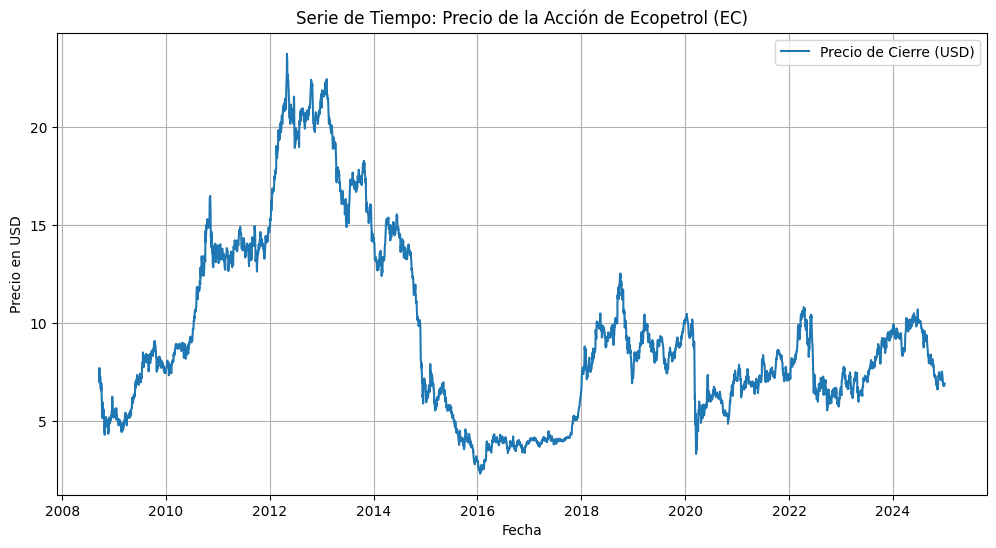

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(df_ecopetrol.index, df_ecopetrol['Close'], label='Precio de Cierre (USD)')
plt.title(f'Serie de Tiempo: Precio de la Acción de Ecopetrol ({ticker_symbol})')
plt.xlabel('Fecha')
plt.ylabel('Precio en USD')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
serie = df_ecopetrol['Close']
serie.index = pd.to_datetime(serie.index)
serie['log_return'] = np.log(serie  / serie.shift(1))

C:\Users\jaayg\AppData\Local\Temp\ipykernel_14708\3214869056.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  serie['log_return'] = np.log(serie  / serie.shift(1))


In [15]:
serie['price_log10'] = np.log10(serie['EC'])

C:\Users\jaayg\AppData\Local\Temp\ipykernel_14708\3184016139.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  serie['price_log10'] = np.log10(serie['EC'])


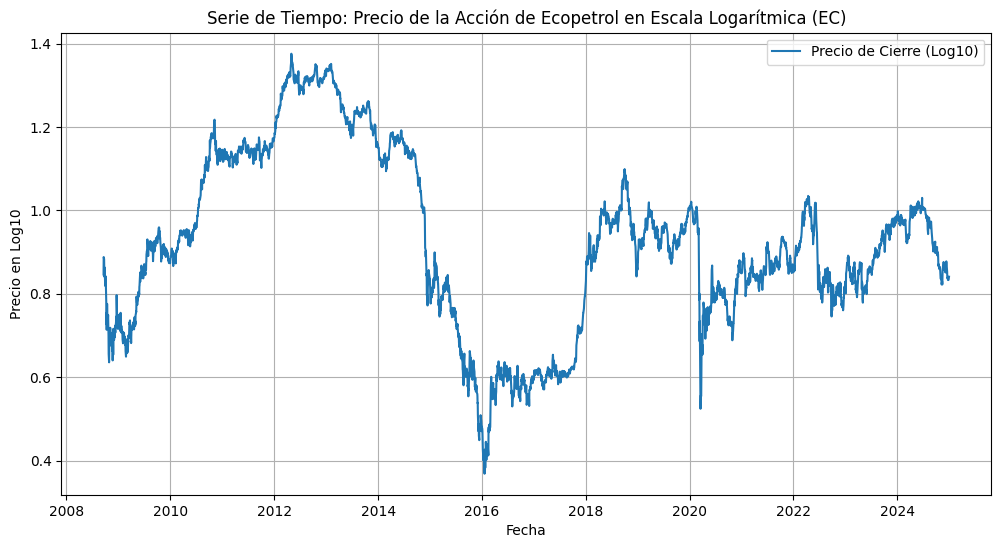

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(serie.index, serie['price_log10'], label='Precio de Cierre (Log10)')
plt.title(f'Serie de Tiempo: Precio de la Acción de Ecopetrol en Escala Logarítmica ({ticker_symbol})')
plt.xlabel('Fecha')
plt.ylabel('Precio en Log10')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
serie.head()

Ticker,EC,log_return
Date,,
2008-09-18,7.015967,NaN
2008-09-19,7.724650,0.096228
2008-09-22,7.639608,-0.011070
2008-09-23,7.072660,-0.077110
2008-09-24,6.930924,-0.020243


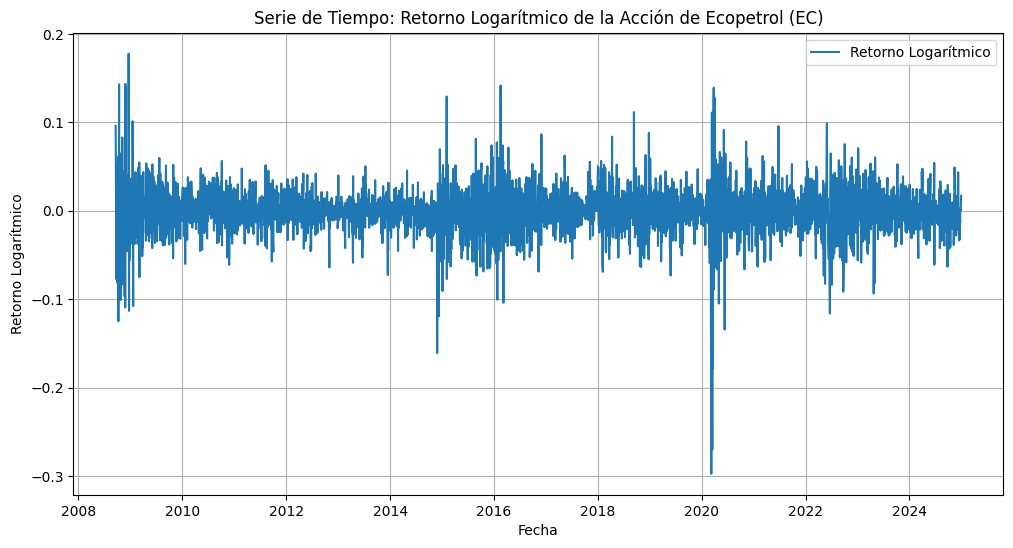

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(serie.index, serie['log_return'], label='Retorno Logarítmico Diario')
plt.title(f'Serie de Tiempo: Retorno Logarítmico Diario de la Acción de Ecopetrol ({ticker_symbol})')
plt.xlabel('Fecha')
plt.ylabel('Retorno Logarítmico Diario')
plt.legend()
plt.grid(True)
plt.show()

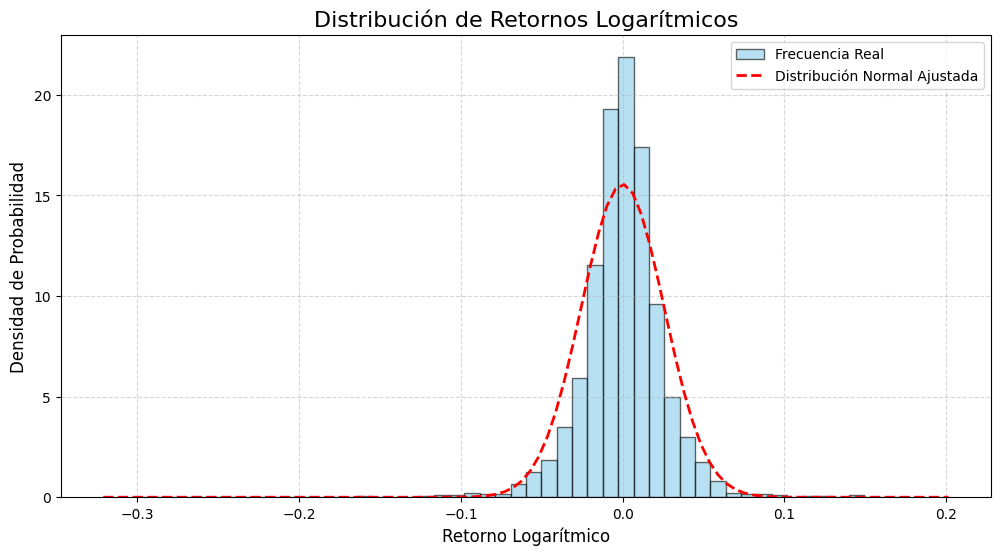

In [14]:
plt.figure(figsize=(12, 6))

count, bins, ignored = plt.hist(serie['log_return'].dropna(), bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Frecuencia Real')

mu, sigma = serie['log_return'].mean(), serie['log_return'].std()

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

plt.plot(x, p, 'r--', linewidth=2, label='Distribución Normal Ajustada')

plt.title('Distribución de Retornos Logarítmicos', fontsize=16)
plt.xlabel('Retorno Logarítmico', fontsize=12)
plt.ylabel('Densidad de Probabilidad', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5) # Cuadrícula manual
plt.legend(loc='best')

plt.show()